# Generate Test Data
Generate synthetic blastocyst scan data (10 cases, 7 slices each) and save
them to `data/` as `.npy` files plus a `metadata.json` index.

**Cases generated:**

| # | Name | Off-centre | Noise | Hatching |
|---|------|-----------|-------|----------|
| 0 | centred_smooth | no | none | no |
| 1 | mild_offcentre | mild | low | no |
| 2 | strong_offcentre | strong | medium | no |
| 3 | noisy_centred | no | high | no |
| 4 | noisy_offcentre | mild | high | no |
| 5 | hatching_centred | no | none | **yes** |
| 6 | hatching_mild_off | mild | low | **yes** |
| 7 | hatching_strong_off | strong | medium | **yes** |
| 8 | hatching_noisy | no | high | **yes** |
| 9 | hatching_noisy_offcentre | mild | high | **yes** |

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from src.generator import BlastocystGenerator, CaseConfig
from src.visualisation import Visualiser

gen  = BlastocystGenerator()
viz  = Visualiser()

## Configuration

In [2]:
DATA_DIR   = "data"          # output folder
HEIGHT     = 64              # pixels per slice (height)
WIDTH      = 64              # pixels per slice (width)
NUM_SLICES = 7               # scanner layers
VOXEL_UM   = 4.0             # physical pixel size in micrometres

## Generate all cases

In [3]:
batch = gen.generate_batch(height=HEIGHT, width=WIDTH, num_slices=NUM_SLICES)
print(f"Generated {len(batch)} cases")
for i, (slices, meta) in enumerate(batch):
    print(f"  [{i:2d}] {meta['name']:<30}  shape={slices.shape}  hatching={meta['hatching']}")

Generated 10 cases
  [ 0] centred_smooth                  shape=(7, 64, 64)  hatching=False
  [ 1] mild_offcentre                  shape=(7, 64, 64)  hatching=False
  [ 2] strong_offcentre                shape=(7, 64, 64)  hatching=False
  [ 3] noisy_centred                   shape=(7, 64, 64)  hatching=False
  [ 4] noisy_offcentre                 shape=(7, 64, 64)  hatching=False
  [ 5] hatching_centred                shape=(7, 64, 64)  hatching=True
  [ 6] hatching_mild_off               shape=(7, 64, 64)  hatching=True
  [ 7] hatching_strong_off             shape=(7, 64, 64)  hatching=True
  [ 8] hatching_noisy                  shape=(7, 64, 64)  hatching=True
  [ 9] hatching_noisy_offcentre        shape=(7, 64, 64)  hatching=True


## Preview — first 4 cases

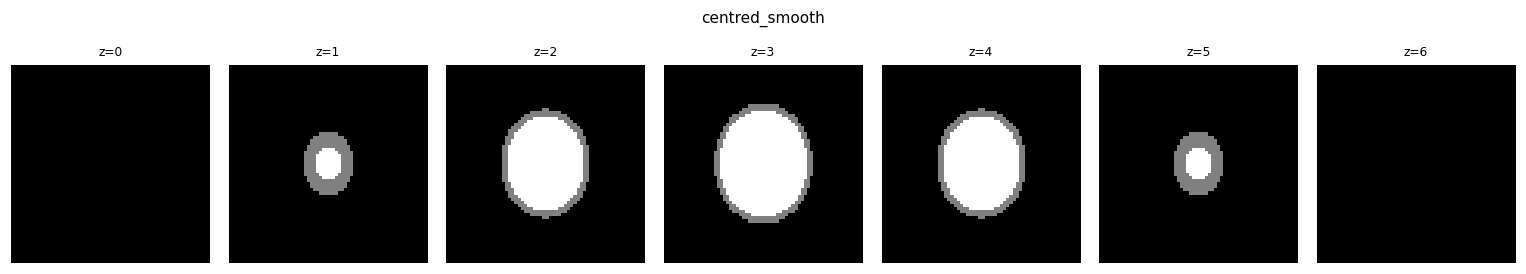

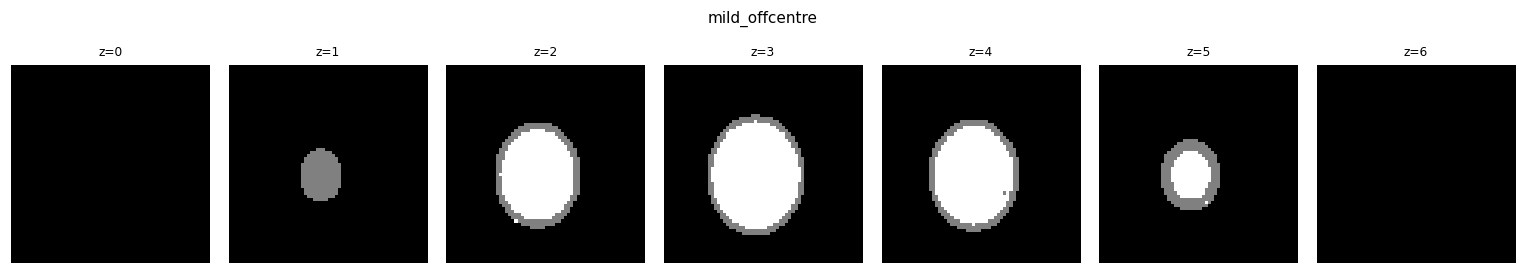

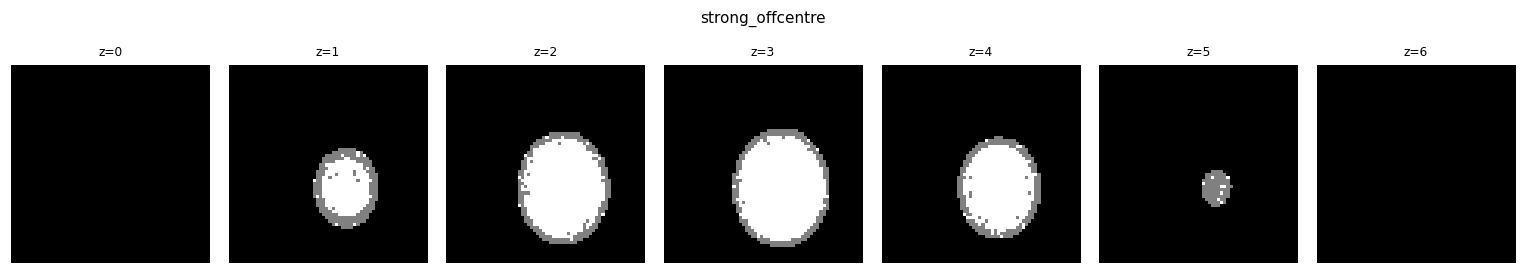

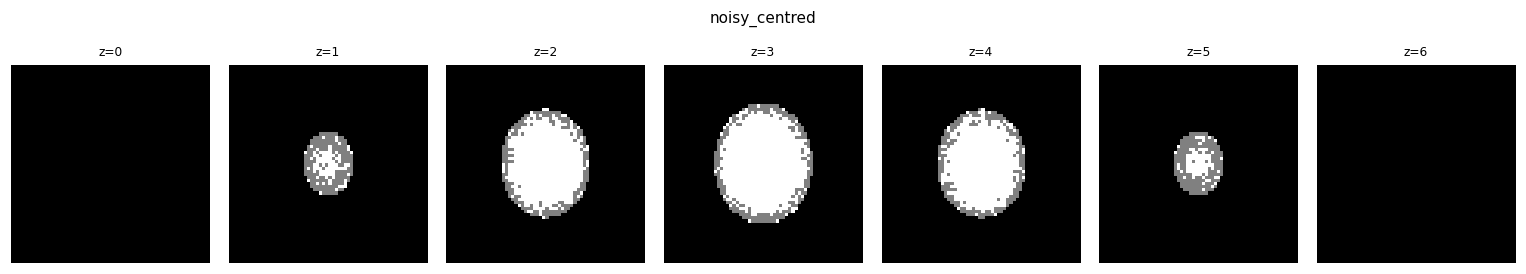

In [4]:
for slices, meta in batch[:4]:
    viz.plot_slices(slices, title=meta["name"])

## Preview — first hatching case

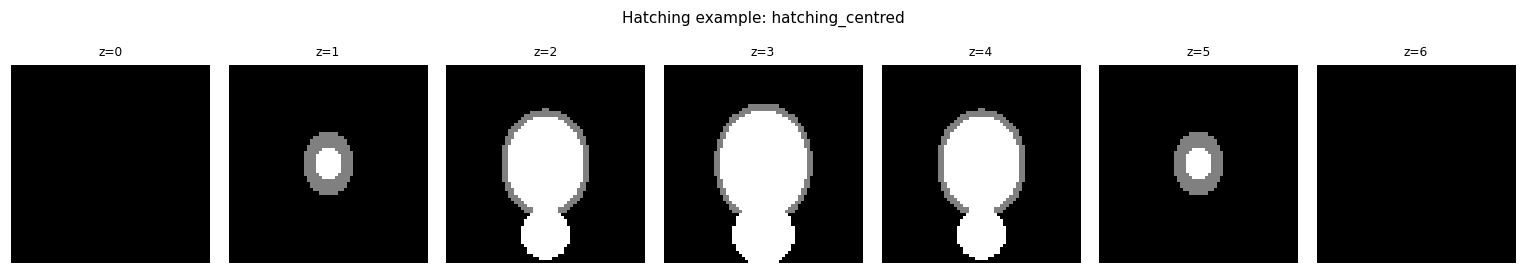

In [5]:
hatching_cases = [(s, m) for s, m in batch if m["hatching"]]
viz.plot_slices(hatching_cases[0][0], title=f"Hatching example: {hatching_cases[0][1]['name']}")

## 3-D shape overview — all 10 cases

Each subplot shows the raw 7-slice stack rendered in 3-D.  
- **Light blue** = zona pellucida shell  
- **Blue** = embryo body (no hatching)  
- **Red** = embryo body + protrusion (hatching)

/Users/skadmin/Embryo Detection/src/visualisation.py:246: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


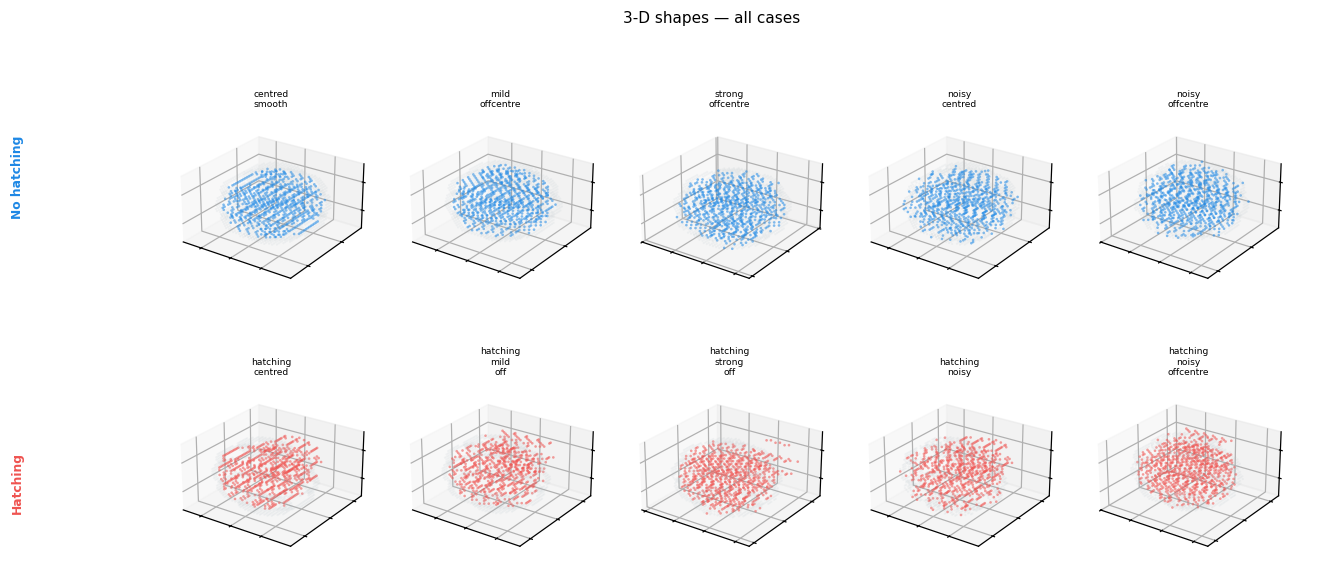

In [6]:
viz.plot_3d_grid(batch)

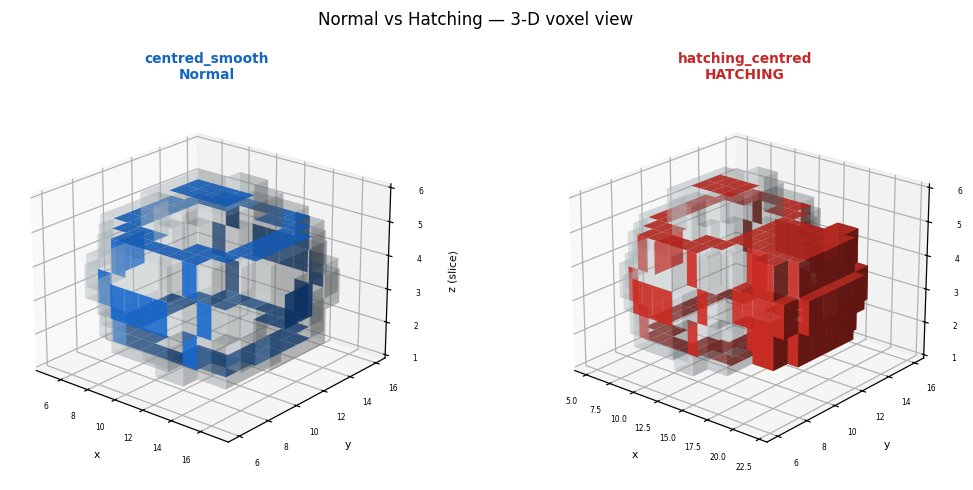

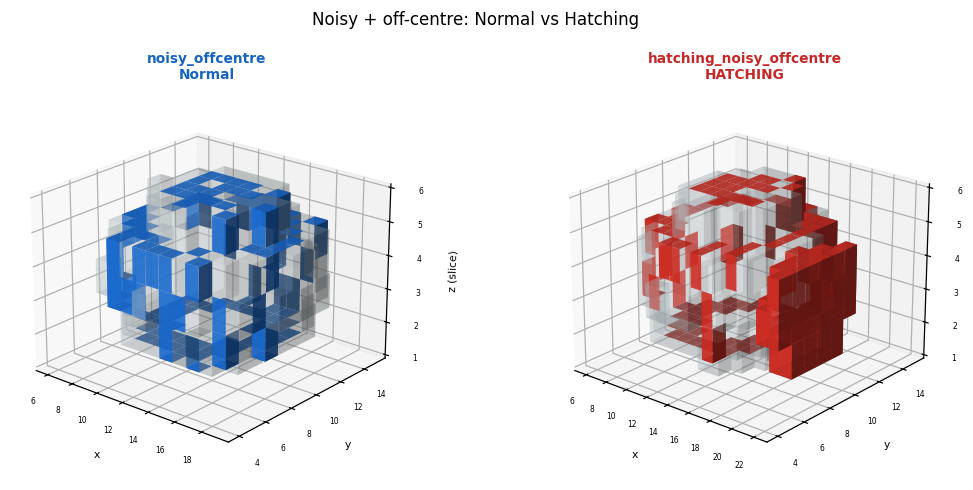

In [7]:
# centred_smooth  vs  hatching_centred  (cleanest pair — no noise, no offset)
normal_case   = next((s, m) for s, m in batch if m["name"] == "centred_smooth")
hatching_case = next((s, m) for s, m in batch if m["name"] == "hatching_centred")
viz.plot_voxel_comparison(normal_case, hatching_case)

# noisy_offcentre  vs  hatching_noisy_offcentre  (realistic pair — noise + offset)
noisy_normal   = next((s, m) for s, m in batch if m["name"] == "noisy_offcentre")
noisy_hatching = next((s, m) for s, m in batch if m["name"] == "hatching_noisy_offcentre")
viz.plot_voxel_comparison(noisy_normal, noisy_hatching,
                          title="Noisy + off-centre: Normal vs Hatching")

## 3-D voxel rendering — normal vs hatching

Detailed block-by-block rendering of one normal case and one hatching case.  
The zona pellucida (translucent grey shell) surrounds the embryo body.  
The hatching protrusion (red) is visible bursting through the zona on the right.

## Intensity distribution across all cases

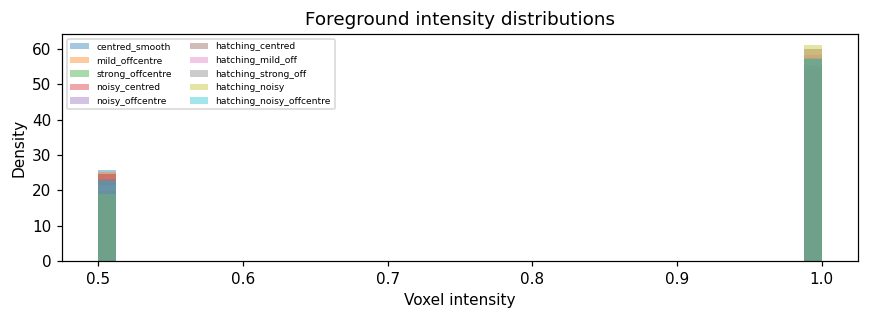

In [8]:
fig, ax = plt.subplots(figsize=(8, 3), dpi=110)
for slices, meta in batch:
    vals = slices[slices > 0].ravel()
    ax.hist(vals, bins=40, alpha=0.4, label=meta["name"], density=True)
ax.set_xlabel("Voxel intensity")
ax.set_ylabel("Density")
ax.set_title("Foreground intensity distributions")
ax.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

## Save to `data/`

In [9]:
meta_path = gen.save_batch(batch, DATA_DIR)
print(f"Saved {len(batch)} cases")
print(f"Metadata → {meta_path}")

import os
for f in sorted(os.listdir(DATA_DIR)):
    size = os.path.getsize(f"{DATA_DIR}/{f}")
    print(f"  {f}  ({size:,} bytes)")

Saved 10 cases
Metadata → data/metadata.json
  case_000_centred_smooth.npy  (114,816 bytes)
  case_001_mild_offcentre.npy  (114,816 bytes)
  case_002_strong_offcentre.npy  (114,816 bytes)
  case_003_noisy_centred.npy  (114,816 bytes)
  case_004_noisy_offcentre.npy  (114,816 bytes)
  case_005_hatching_centred.npy  (114,816 bytes)
  case_006_hatching_mild_off.npy  (114,816 bytes)
  case_007_hatching_strong_off.npy  (114,816 bytes)
  case_008_hatching_noisy.npy  (114,816 bytes)
  case_009_hatching_noisy_offcentre.npy  (114,816 bytes)
  metadata.json  (3,680 bytes)
  results.csv  (893 bytes)
